In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.optim import lr_scheduler
from PIL import Image
import matplotlib.pyplot as plt

In [7]:
# 1. 检测 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前使用的设备: {device}")

# 显示 GPU 的名称（如果可用）
if torch.cuda.is_available():
    print(f"GPU 名称: {torch.cuda.get_device_name(0)}")

当前使用的设备: cuda
GPU 名称: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [ ]:
# 2. 数据预处理 - 必须包含 Resize

# 检测 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 训练集：增加数据增强
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 测试集/推理：保持简洁
test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 加载 CIFAR-10
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

In [ ]:
# 3. 定义 AlexNet
class AlexNet(nn.Module):
    def __init__(self, num_classes=10): # CIFAR-10 有 10 个类
        super(AlexNet, self).__init__() # 调用父类的构造函数, 以确保正确初始化
        self.features = nn.Sequential( # 定义卷积层部分
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential( # 定义全连接层部分
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# 4. 初始化模型并搬运至 GPU
model = AlexNet(num_classes=10).to(device)

In [8]:
criterion = nn.CrossEntropyLoss()
# 学习率设为 0.01，配合动量
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
# 每 10 个 Epoch 降低一次学习率
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

### 2个epoch

In [ ]:
print("开始训练...")
model.train()
for epoch in range(2): # 演示运行 2 个 epoch
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # 关键步骤：将输入数据和标签也传送到 GPU
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 100 == 99:
            print(f'[Epoch {epoch + 1}, Batch {i + 1}] loss: {running_loss / 100:.3f}')
            running_loss = 0.0

print("训练完成！")

开始训练...
[Epoch 1, Batch 100] loss: 2.303
[Epoch 1, Batch 200] loss: 2.300
[Epoch 1, Batch 300] loss: 2.177
[Epoch 1, Batch 400] loss: 2.028
[Epoch 1, Batch 500] loss: 1.859
[Epoch 1, Batch 600] loss: 1.773
[Epoch 1, Batch 700] loss: 1.664
[Epoch 2, Batch 100] loss: 1.518
[Epoch 2, Batch 200] loss: 1.475
[Epoch 2, Batch 300] loss: 1.407
[Epoch 2, Batch 400] loss: 1.367
[Epoch 2, Batch 500] loss: 1.278
[Epoch 2, Batch 600] loss: 1.255
[Epoch 2, Batch 700] loss: 1.233
训练完成！


In [12]:
# 保存最终成果
torch.save(model.state_dict(), 'model/alexnet_simple_cifar10.pth')
print("权重已保存！")

权重已保存！


### 大量的epoch

In [ ]:

print("开始特训模型...")
num_epochs = 20 # 如果时间充裕，可以改为 50

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    scheduler.step()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(trainloader):.4f}")


In [ ]:
# 保存最终成果
torch.save(model.state_dict(), 'alexnet_pro_cifar10.pth')
print("训练完成且权重已保存！")

### 使用模型

In [ ]:
def predict_your_dog(img_path):
    # 标签映射
    classes = ('airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck')
    
    # 加载图片
    img = Image.open(img_path).convert('RGB')
    img_tensor = test_transform(img).unsqueeze(0).to(device)
    
    # 推理
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
        confidence, predicted = torch.max(probabilities, 0)
    
    # 显示结果
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {classes[predicted.item()]} ({confidence.item()*100:.2f}%)")
    plt.show()

## Colab

### 上传文件到colab

In [12]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### Colab调用模型

In [ ]:
# 建议在云盘里建一个专门的文件夹，比如 'models'
import os
save_path = '/content/drive/MyDrive/Colab/models'
if not os.path.exists(save_path):
    os.makedirs(save_path)

# 保存权重
torch.save(model.state_dict(), os.path.join(save_path, 'alexnet_pro_best.pth'))
print(f"模型已保存至 Google Drive: {save_path}")

Prediction: dog (46.26%)


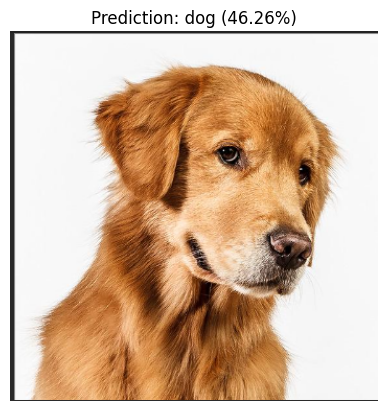

In [48]:
import torch
import torch.nn as nn
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 1. 确保设备正确
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. 实例化并加载训练好的权重 (确保 AlexNet 类已在上方定义)
model = AlexNet(num_classes=10).to(device)
model.load_state_dict(torch.load('alexnet_cifar10.pth', map_location=device))
model.eval()

# 3. 图像预处理
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 4. 英文标签定义 (标准的 CIFAR-10 类别)
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck')

def run_inference(img_path):
    # 加载图片
    try:
        img = Image.open(img_path).convert('RGB')
    except FileNotFoundError:
        print(f"Error: Cannot find image at {img_path}")
        return

    img_tensor = transform(img).unsqueeze(0).to(device)
    
    # 推理
    with torch.no_grad():
        output = model(img_tensor)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
        confidence, predicted = torch.max(probabilities, 0)
    
    # 可视化结果 (英文标题)
    plt.imshow(img)
    plt.axis('off')
    result_text = f"Prediction: {classes[predicted.item()]} ({confidence.item()*100:.2f}%)"
    plt.title(result_text)
    print(result_text) # 同时在控制台打印输出
    plt.show()

# 5. 执行推理 (请确保路径指向你 Drive 里的真实位置)
run_inference('/content/drive/MyDrive/dog.png')

## 论文训练完成的模型

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 156MB/s]  


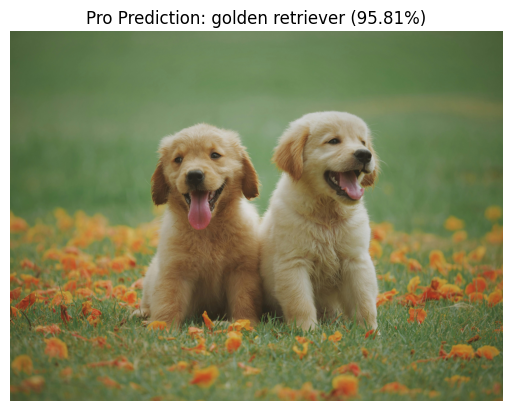

In [23]:
import torchvision.models as models

# 1. 加载官方预训练好的“满级”模型
# 这个模型认识 1000 种东西，而不仅仅是 10 种
weights = models.AlexNet_Weights.IMAGENET1K_V1
model_pro = models.alexnet(weights=weights).to(device)
model_pro.eval()

# 2. 获取 ImageNet 的 1000 个类别标签
categories = weights.meta["categories"]

def run_pro_inference(img_path):
    img = Image.open(img_path).convert('RGB')
    # 使用官方配套的预处理逻辑
    preprocess = weights.transforms()
    img_tensor = preprocess(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model_pro(img_tensor)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
        confidence, predicted = torch.max(probabilities, 0)
    
    plt.imshow(img)
    plt.title(f"Pro Prediction: {categories[predicted.item()]} ({confidence.item()*100:.2f}%)")
    plt.axis('off')
    plt.show()

# 再次测试那张照片
run_pro_inference('/content/drive/MyDrive/pexels-photo-1108099.jpeg')

## 增强模型

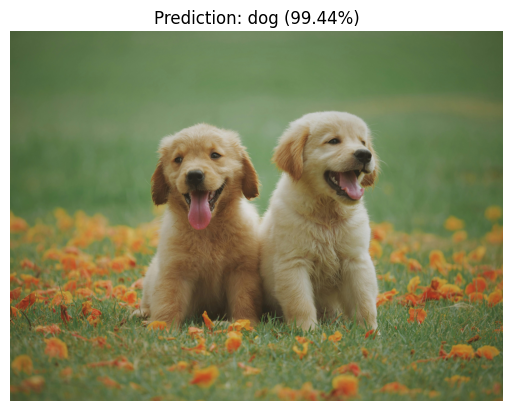

In [ ]:
# 调用测试（请确保路径正确）
image_path = '/content/drive/MyDrive/Colab/images/dog.png' # 替换为你实际的图片路径
predict_your_dog(image_path)

In [14]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [15]:
# 查看 MyDrive 下的内容
!ls /content/drive/MyDrive/Colab/images/

2-dogs.jpeg  dog.jpeg  dog.png
